# Классификатор лесных грибов

In [3]:
!pip install split-folders tqdm

**Установка необходимых библиотек**

In [4]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [5]:
# we will verify that GPU is enabled for this notebook
# following should print: CUDA is available!  Training on GPU ...
#
# if it prints otherwise, then you need to enable GPU:
# from Menu > Runtime > Change Runtime Type > Hardware Accelerator > GPU

import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is not available.  Training on CPU ...


In [4]:
!nvidia-smi
import torch
torch.cuda.is_available()

Sun Mar  8 04:41:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P8             12W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

True

In [6]:
from PIL import ImageFile
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.applications.efficientnet import preprocess_input
from collections import Counter
from sklearn.utils.class_weight import compute_class_weight
import random
import pandas as pd
from pandas import DataFrame as df
import shutil
from sklearn.model_selection import train_test_split
from pathlib import Path
import matplotlib.image as mpimg
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [7]:
ImageFile.LOAD_TRUNCATED_IMAGES = True # Загрузка, в том числе и поврежденных файлов, чтобы не прерывать процесс

In [10]:
!pip install kagglehub

In [8]:
import kagglehub

In [9]:
data_dir = kagglehub.dataset_download("maysee/mushrooms-classification-common-genuss-images") # Берем датасет с сайта Kaggle для классификации лесных грибов
output_dir = "mushrooms_split"   # Директория для сохранения разделенного датасета



100%|██████████| 1.85G/1.85G [00:26<00:00, 75.3MB/s]

Extracting files...


In [10]:
''' Обрезаем изображения до 240 px, чтобы не перегружать модель: этого хватит для качественной классификации,
    устанавливаем размер одного батча для файн-тюнинга, количество эпох обучения и количество слоев, которые будут заморожены.
'''

IMG_SIZE = 240
BATCH_SIZE = 16
EPOCHS = 20
FINE_TUNE_AT = 100
MODEL_SAVE_PATH = "efficient_model.h5"

'''
  Разбиваем датасет на тренировочную и валидационную выборкив отношении 80% к 20%
'''

# Собираем все изображения
all_images = []
all_labels = []

data_dir = os.path.join(data_dir, 'Mushrooms')
# Проходим по всем папкам классов
for class_dir in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_dir)
    if not os.path.isdir(class_path):
        continue

    # Собираем все изображения в этом классе
    for img_file in os.listdir(class_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_images.append(os.path.join(class_path, img_file))
            all_labels.append(class_dir)

print(f"Всего изображений: {len(all_images)}")
print(f"Всего классов: {len(set(all_labels))}")

# Разделяем на train/val (80/20) с сохранением пропорций
train_imgs, val_imgs = train_test_split(
    all_images,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)

print(f"Train: {len(train_imgs)} изображений")
print(f"Val: {len(val_imgs)} изображений")

# Создаем структуру папок
for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs)]:
    split_dir = os.path.join(output_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)

    for img_path in split_imgs:
        # Определяем класс
        class_name = Path(img_path).parent.name
        # Создаем папку класса
        class_dir = os.path.join(split_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)
        # Копируем файл
        shutil.copy2(img_path, os.path.join(class_dir, os.path.basename(img_path)))

print(f"Датасет разделен и сохранен в {output_dir}")
print(f"Train: {os.path.join(output_dir, 'train')}")
print(f"Val: {os.path.join(output_dir, 'val')}")


Всего изображений: 6714
Всего классов: 9
Train: 5371 изображений
Val: 1343 изображений
Датасет разделен и сохранен в mushrooms_split
Train: mushrooms_split/train
Val: mushrooms_split/val


In [11]:
train_dir = os.path.join(output_dir, 'train')
val_dir = os.path.join(output_dir, 'val')

**Посмотрим изображения из датасета, на распределение классов и статистику**

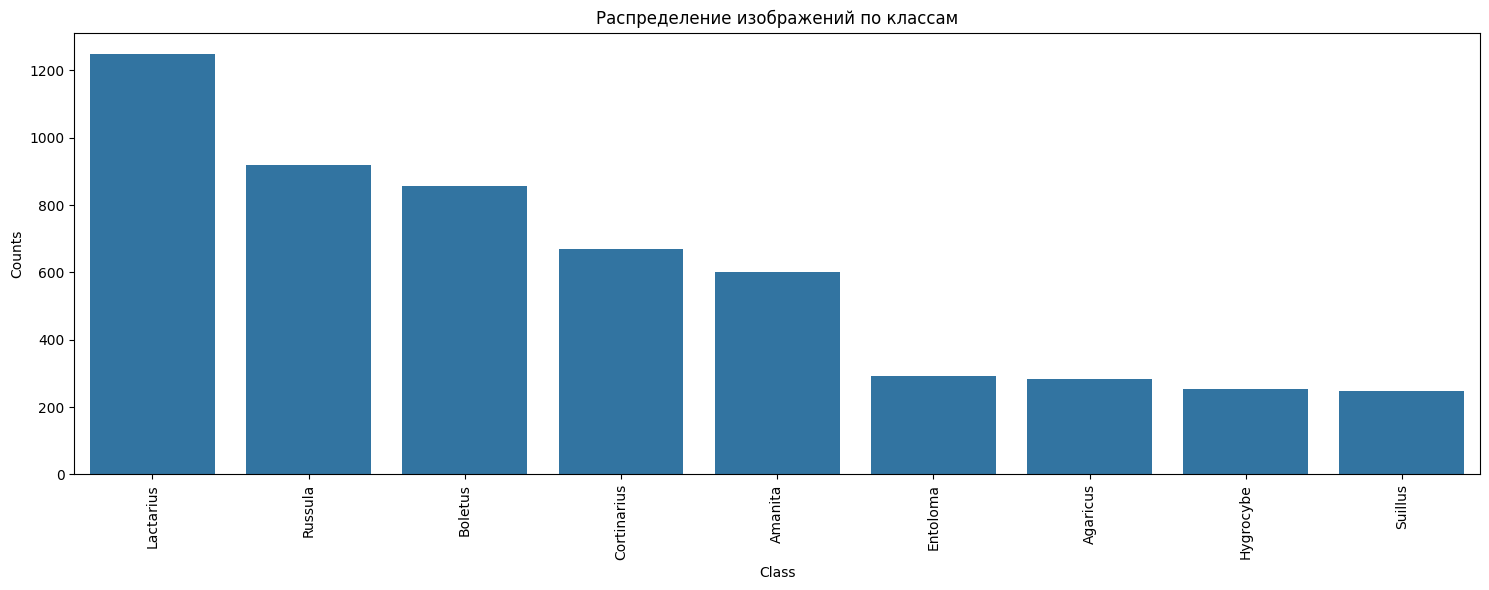

In [12]:
class_names = os.listdir(train_dir)
counts = []
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    counts.append(len(os.listdir(class_path)))
columns = df({'Class' : class_names, 'Counts' : counts})
columns = columns.sort_values('Counts', ascending=False)
plt.figure(figsize=(15, 6))
sns.barplot(data=columns, x='Class', y='Counts')
plt.title('Распределение изображений по классам')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

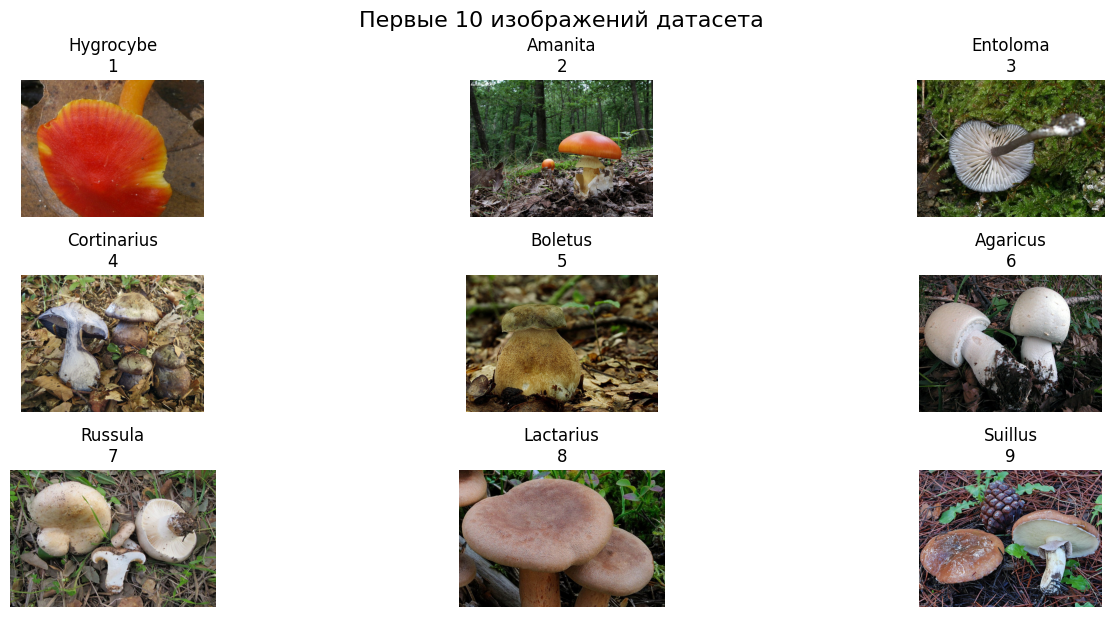

In [13]:
firsts = [os.path.join(train_dir, f'{cl}/{os.listdir(os.path.join(train_dir, cl))[0]}') for cl in os.listdir(train_dir)]
fig, axes = plt.subplots(3, 3, figsize=(15, 6))
axes = axes.ravel()

for i, img_path in enumerate(firsts):
    # Загружаем изображение
    img = mpimg.imread(img_path)

    # Получаем название класса из пути
    class_name = Path(img_path).parent.name

    # Отображаем
    axes[i].imshow(img)
    axes[i].set_title(f"{class_name}\n{i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle("Первые 10 изображений датасета", fontsize=16, y=1.02)
plt.show()

**Балансировка классов**

In [14]:
# Собираем полные пути для изображений, принадлежащим всем классам
classes = sorted(os.listdir(train_dir))
all_image_paths = []
all_labels = []

for idx, cls in enumerate(classes):
    cls_folder = os.path.join(train_dir, cls)
    files = [os.path.join(cls_folder, f) for f in os.listdir(cls_folder)]
    all_image_paths.extend(files)
    all_labels.extend([cls] * len(files))

# Балансировка классов, повторяем изображения, если их в классе мало
from collections import Counter
count_per_class = Counter(all_labels)


max_count = max(count_per_class.values())
balanced_paths = []
balanced_labels = []

for cls in classes:
    cls_paths = [p for p, l in zip(all_image_paths, all_labels) if l == cls]
    oversampled = np.random.choice(cls_paths, size=max_count, replace=True)
    balanced_paths.extend(oversampled)
    balanced_labels.extend([cls] * max_count)

# Перераспределение изображений в случайном порядке
combined = list(zip(balanced_paths, balanced_labels))
random.shuffle(combined)
balanced_paths, balanced_labels = zip(*combined)

print("Распределение по классам:", Counter(balanced_labels))



Распределение по классам: Counter({'Agaricus': 1250, 'Boletus': 1250, 'Russula': 1250, 'Cortinarius': 1250, 'Hygrocybe': 1250, 'Entoloma': 1250, 'Suillus': 1250, 'Lactarius': 1250, 'Amanita': 1250})


In [15]:
# Создание датафрейма для тренировки
train_df = pd.DataFrame({"filename": balanced_paths, "class": balanced_labels})

# Аугментация данных для расширения тренировочного датасета
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="reflect"
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)
print("Индексы классов:", train_generator.class_indices)



Found 11250 validated image filenames belonging to 9 classes.
Found 1343 images belonging to 9 classes.
Индексы классов: {'Agaricus': 0, 'Amanita': 1, 'Boletus': 2, 'Cortinarius': 3, 'Entoloma': 4, 'Hygrocybe': 5, 'Lactarius': 6, 'Russula': 7, 'Suillus': 8}


**Архитектура модели**

In [19]:
# Используем предобученную модель EfficientNetB1, удаляем последний слой и добавляем pooling в конец базовой модели
base_model = EfficientNetB1(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    pooling="avg"
)

base_model.trainable = False # Замораживаем базовые слои модели для fine-tuning

# Добавление новых слоев модели
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)) # Входной слой
x = base_model(inputs, training=False)
x = layers.Dropout(0.3)(x) # Дропаут для борьбы с переобучением - на каждом этапе отключается 30% нейронов, выбранных произвольно
x = layers.Dense(512, activation="swish")(x) # Полносвязанный слой
x = layers.BatchNormalization()(x) # Нормализация для ускорения обучения
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x) # Последний солносвязанный слой

model = models.Model(inputs, outputs) # Инициализация модели



27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


**Описание модели**

In [20]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb1 (Functional)     │ (None, 1280)           │     6,575,239 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,237,776 (27.61 MB)

 Trainable params: 661,513 (2.52 MB)

 Non-trainable params: 6,576,263 (25.09 MB)

In [21]:
#  Callbacks
# Сохранение лучшей модели
checkpoint_cb = callbacks.ModelCheckpoint(
    "best_efficientnetb1.h5",
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)
# Уменьшение скорости обучения в случае, если метрика не улучшается
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)
# Прекращает обучение, если метрика не улучшается в течение 8 эпох -> борьба с переобучением
earlystop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)



**Первый этап обучения**

In [2]:
labels = [train_generator.class_indices[c] for c in balanced_labels]
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

history1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[checkpoint_cb, reduce_lr, earlystop]
)



NameError: name 'balanced_labels' is not defined

**Fine-tuning**

In [23]:
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[checkpoint_cb, reduce_lr, earlystop],
    initial_epoch=history1.epoch[-1] if hasattr(history1, "epoch") else 0
)



Epoch 10/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 379s 416ms/step - accuracy: 0.6548 - loss: 1.3511 - val_accuracy: 0.8101 - val_loss: 0.6193 - learning_rate: 1.0000e-04
Epoch 11/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.8646 - loss: 0.4152

704/704 ━━━━━━━━━━━━━━━━━━━━ 231s 328ms/step - accuracy: 0.8646 - loss: 0.4151 - val_accuracy: 0.8392 - val_loss: 0.5061 - learning_rate: 1.0000e-04
Epoch 12/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 232s 330ms/step - accuracy: 0.9250 - loss: 0.2272 - val_accuracy: 0.8340 - val_loss: 0.5374 - learning_rate: 1.0000e-04
Epoch 13/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.9412 - loss: 0.1723

704/704 ━━━━━━━━━━━━━━━━━━━━ 260s 326ms/step - accuracy: 0.9412 - loss: 0.1723 - val_accuracy: 0.8622 - val_loss: 0.4529 - learning_rate: 1.0000e-04
Epoch 14/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 234s 332ms/step - accuracy: 0.9565 - loss: 0.1302 - val_accuracy: 0.8511 - val_loss: 0.5338 - learning_rate: 1.0000e-04
Epoch 15/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9617 - loss: 0.1107

704/704 ━━━━━━━━━━━━━━━━━━━━ 232s 330ms/step - accuracy: 0.9617 - loss: 0.1107 - val_accuracy: 0.8816 - val_loss: 0.3739 - learning_rate: 1.0000e-04
Epoch 16/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 232s 330ms/step - accuracy: 0.9680 - loss: 0.0974 - val_accuracy: 0.8905 - val_loss: 0.3908 - learning_rate: 1.0000e-04
Epoch 17/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.9755 - loss: 0.0747

704/704 ━━━━━━━━━━━━━━━━━━━━ 230s 327ms/step - accuracy: 0.9755 - loss: 0.0747 - val_accuracy: 0.9032 - val_loss: 0.3472 - learning_rate: 1.0000e-04
Epoch 18/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 229s 326ms/step - accuracy: 0.9743 - loss: 0.0775 - val_accuracy: 0.9010 - val_loss: 0.3777 - learning_rate: 1.0000e-04
Epoch 19/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 236s 335ms/step - accuracy: 0.9774 - loss: 0.0654 - val_accuracy: 0.9032 - val_loss: 0.3721 - learning_rate: 1.0000e-04
Epoch 20/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9788 - loss: 0.0570
Epoch 20: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
704/704 ━━━━━━━━━━━━━━━━━━━━ 231s 327ms/step - accuracy: 0.9788 - loss: 0.0570 - val_accuracy: 0.8943 - val_loss: 0.4048 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 17.


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=efficient_model.

In [27]:
# Сохранение финальной модели
model.save(MODEL_SAVE_PATH)
print(f"Model saved to {MODEL_SAVE_PATH}")

# Вывод результатов обучения
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation loss: {val_loss:.4f}, accuracy: {val_acc:.4f}")

Model saved to efficient_model.h5
84/84 ━━━━━━━━━━━━━━━━━━━━ 8s 98ms/step - accuracy: 0.9076 - loss: 0.2982
Validation loss: 0.3472, accuracy: 0.9032


**Визуализация динамики обучения**

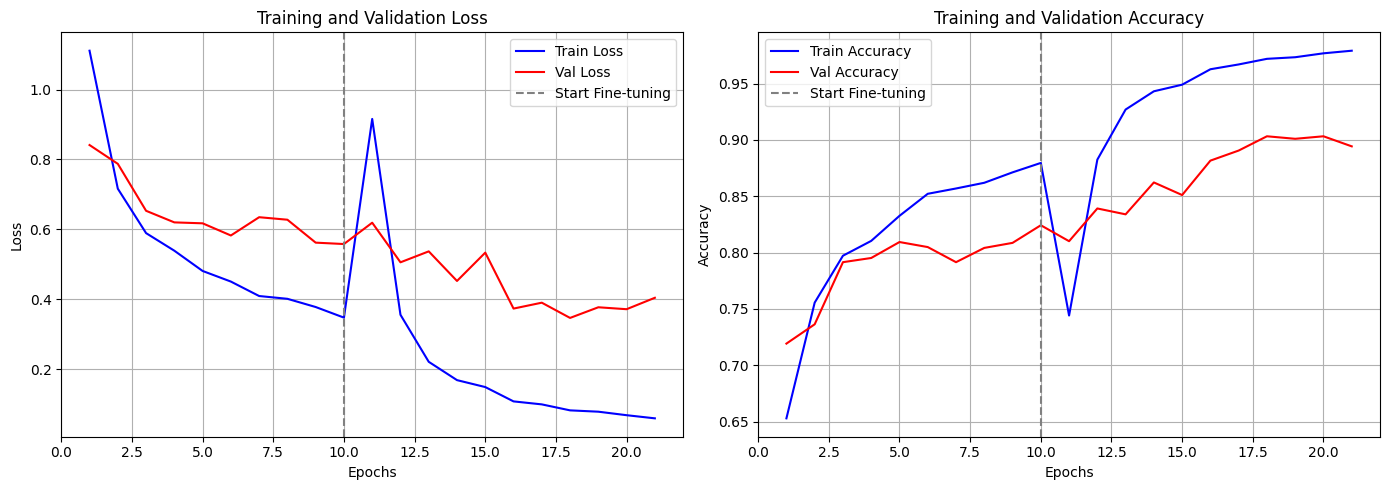

In [24]:
history1_dict = history1.history
history2_dict = history2.history

# Объединение истории обучения
combined_history = {}
for key in history1_dict.keys():
    if key in history2_dict:
        combined_history[key] = history1_dict[key] + history2_dict[key]
    else:
        combined_history[key] = history1_dict[key]

epochs_stage1 = len(history1_dict['loss'])
epochs_stage2 = len(history2_dict['loss'])
total_epochs = range(1, epochs_stage1 + epochs_stage2 + 1)

plt.figure(figsize=(14, 5))

# Функция потерь
plt.subplot(1, 2, 1)
plt.plot(total_epochs, combined_history['loss'], 'b-', label='Train Loss')
plt.plot(total_epochs, combined_history['val_loss'], 'r-', label='Val Loss')
plt.axvline(x=epochs_stage1, color='gray', linestyle='--', label='Start Fine-tuning')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# График 2: Точность (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(total_epochs, combined_history['accuracy'], 'b-', label='Train Accuracy')
plt.plot(total_epochs, combined_history['val_accuracy'], 'r-', label='Val Accuracy')
# Добавляем вертикальную линию
plt.axvline(x=epochs_stage1, color='gray', linestyle='--', label='Start Fine-tuning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**CONFUSION MATRIX**

In [18]:
from tensorflow.keras.models import load_model
model = load_model(MODEL_SAVE_PATH) # Загрузка сохраненной модели

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'efficient_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

84/84 ━━━━━━━━━━━━━━━━━━━━ 27s 200ms/step
=== Classification Report ===
              precision    recall  f1-score   support

    Agaricus     0.8289    0.9000    0.8630        70
     Amanita     0.9110    0.8867    0.8986       150
     Boletus     0.9369    0.9674    0.9519       215
 Cortinarius     0.9119    0.8683    0.8896       167
    Entoloma     0.8378    0.8493    0.8435        73
   Hygrocybe     0.9672    0.9365    0.9516        63
   Lactarius     0.9555    0.8914    0.9223       313
     Russula     0.8635    0.9348    0.8977       230
     Suillus     0.7656    0.7903    0.7778        62

    accuracy                         0.9032      1343
   macro avg     0.8865    0.8916    0.8885      1343
weighted avg     0.9052    0.9032    0.9035      1343



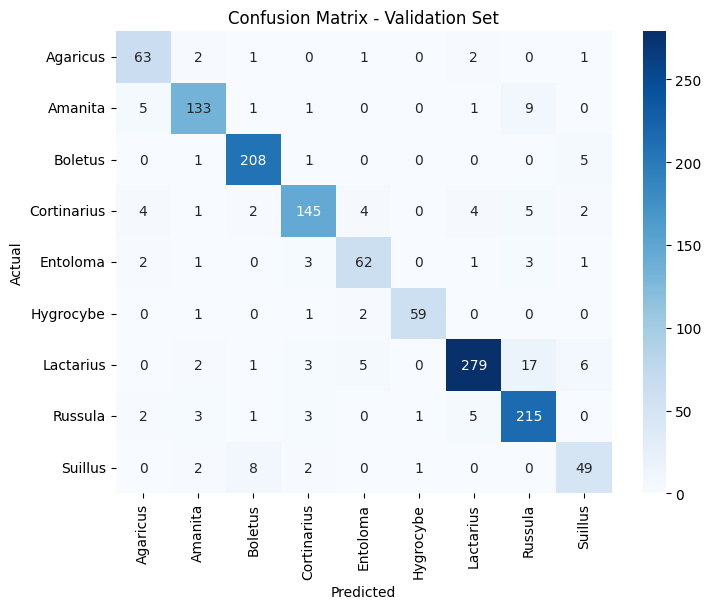

In [25]:

# Предсказания на валидационной выборке
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

y_pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

#  Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Validation Set")
plt.show()
